In [74]:
# ------------------------------
# STEP 1: Import libraries
# ------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [34]:
# -----------------------------------------------------
# STEP 2: Load data safely
# -----------------------------------------------------

df = pd.read_excel('/content/raw_zomato_data.xlsx')
print("Data Loaded Successfully")
print(df.head())

Data Loaded Successfully
                    name online_order book_table   rate  votes  \
0                  Jalsa          Yes        Yes  4.1/5    775   
1         Spice Elephant          Yes         No  4.1/5    787   
2        San Churro Cafe          Yes         No  3.8/5    918   
3  Addhuri Udupi Bhojana           No         No  3.7/5     88   
4          Grand Village           No         No  3.8/5    166   

   approx_cost(for two people) listed_in(type)  
0                          800          Buffet  
1                          800          Buffet  
2                          800          Buffet  
3                          300          Buffet  
4                          600          Buffet  


In [47]:
# --------------------------------
# STEP 3: Basic Info
# --------------------------------

In [46]:
print("\nShape:", df.shape)


Shape: (148, 7)


In [44]:
print("\nColumns:", df.columns)


Columns: Index(['name', 'online_order', 'book_table', 'rate', 'votes',
       'approx_cost(for two people)', 'listed_in(type)'],
      dtype='object')


In [43]:
print("\nInfo:")
print(df.info())


Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   name                         148 non-null    object 
 1   online_order                 148 non-null    object 
 2   book_table                   148 non-null    object 
 3   rate                         148 non-null    float64
 4   votes                        148 non-null    int64  
 5   approx_cost(for two people)  148 non-null    int64  
 6   listed_in(type)              148 non-null    object 
dtypes: float64(1), int64(2), object(4)
memory usage: 8.2+ KB
None


In [42]:
print("\nDescription:")
print(df.describe())


Description:
             rate        votes  approx_cost(for two people)
count  148.000000   148.000000                   148.000000
mean     3.633108   264.810811                   418.243243
std      0.402271   653.676951                   223.085098
min      2.600000     0.000000                   100.000000
25%      3.300000     6.750000                   200.000000
50%      3.700000    43.500000                   400.000000
75%      3.900000   221.750000                   600.000000
max      4.600000  4884.000000                   950.000000


In [37]:
# -----------------------------------------------------
# STEP 4: Cleaning
# -----------------------------------------------------

In [38]:
# Checking null values
print("Missing values in each column:")
df.isnull().sum()

Missing values in each column:


,0
name,0
online_order,0
book_table,0
rate,0
votes,0
approx_cost(for two people),0
listed_in(type),0


In [39]:
# Remove null values
df = df.dropna()

In [48]:
#Clean Rating
df['rate'] = df['rate'].astype(str)
df['rate'] = df['rate'].str.replace('/5', '', regex=False)
df['rate'] = pd.to_numeric(df['rate'], errors='coerce')
df.rate

,rate
0,4.1
1,4.1
2,3.8
3,3.7
4,3.8
...,...
143,3.3
144,3.3
145,4.0
146,3.0


In [49]:
#Clean Cost
df['approx_cost(for two people)'] = df['approx_cost(for two people)'].astype(str)
df['approx_cost(for two people)'] = df['approx_cost(for two people)'].str.replace(',', '', regex=False)
df['approx_cost(for two people)'] = pd.to_numeric(df['approx_cost(for two people)'], errors='coerce')
df['approx_cost(for two people)']

,approx_cost(for two people)
0,800
1,800
2,800
3,300
4,600
...,...
143,100
144,150
145,450
146,800


In [51]:
# Remove null again after conversion
df = df.dropna()

In [54]:
# Remove duplicates
df = df.drop_duplicates()

print("\nAfter Cleaning:", df.shape)


After Cleaning: (148, 7)


In [55]:
#Check Cleaned Data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   name                         148 non-null    object 
 1   online_order                 148 non-null    object 
 2   book_table                   148 non-null    object 
 3   rate                         148 non-null    float64
 4   votes                        148 non-null    int64  
 5   approx_cost(for two people)  148 non-null    int64  
 6   listed_in(type)              148 non-null    object 
dtypes: float64(1), int64(2), object(4)
memory usage: 8.2+ KB


In [56]:
print("Data Cleaning Done Successfully")

Data Cleaning Done Successfully


In [59]:
# ----------------------------------
# STEP 5: EDA (Analysis)
# ----------------------------------

print("\n--- BASIC ANALYSIS ---")


--- BASIC ANALYSIS ---


In [60]:
# 1. Online Order Count
print("\nOnline Order Count:\n")
print(df['online_order'].value_counts())


Online Order Count:

online_order
No     90
Yes    58
Name: count, dtype: int64


In [61]:
# 2. Table Booking Count
print("\nTable Booking Count:\n")
print(df['book_table'].value_counts())


Table Booking Count:

book_table
No     140
Yes      8
Name: count, dtype: int64


In [69]:
# 3. Restaurant Types
print("\nRestaurant Types:\n")
print(df['listed_in(type)'].value_counts())


Restaurant Types:

listed_in(type)
Dining    110
Cafes      23
other       8
Buffet      7
Name: count, dtype: int64


In [70]:
# 4. Average Rating
print("\nAverage Rating:\n", df['rate'].mean())


Average Rating:
 3.6331081081081082


In [64]:
# 5. Average Cost
print("\nAverage Cost:\n", df['approx_cost(for two people)'].mean())


Average Cost:
 418.2432432432432


In [65]:
# 6. Most Popular Restaurants (based on votes)
print("\nTop Restaurants by Votes:\n")
print(df[['name', 'votes']].sort_values(by='votes', ascending=False).head(5))


Top Restaurants by Votes:

                 name  votes
38  Empire Restaurant   4884
86      Meghana Foods   4401
7              Onesta   2556
44             Onesta   2556
65        Kabab Magic   1720


In [66]:
# 7. Rating distribution count
print("\nRating Distribution Count:\n")
print(df['rate'].value_counts())


Rating Distribution Count:

rate
3.8    20
3.7    15
3.3    14
3.4    12
4.1    11
3.6    11
4.0    10
3.9    10
4.2     8
3.2     7
3.1     7
2.9     7
3.5     6
3.0     2
4.6     2
2.8     2
4.4     2
4.3     1
2.6     1
Name: count, dtype: int64


In [ ]:
# ----------------------------------
# STEP 6: Graphs
# ----------------------------------

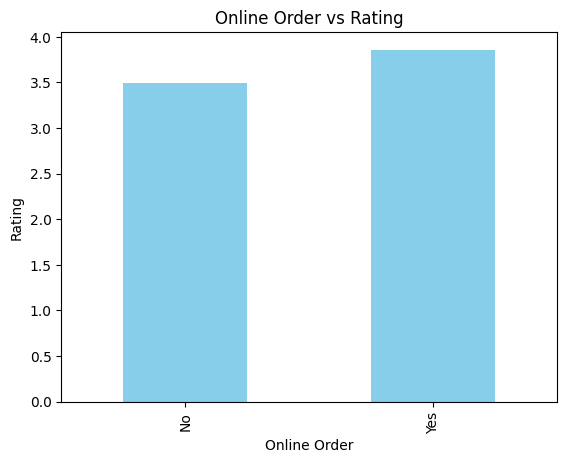

In [84]:
# 1. Online Order vs Rating

df.groupby('online_order')['rate'].mean().plot(kind='bar', color='skyblue')
plt.xlabel("Online Order")
plt.ylabel("Rating")
plt.title("Online Order vs Rating")
plt.show()

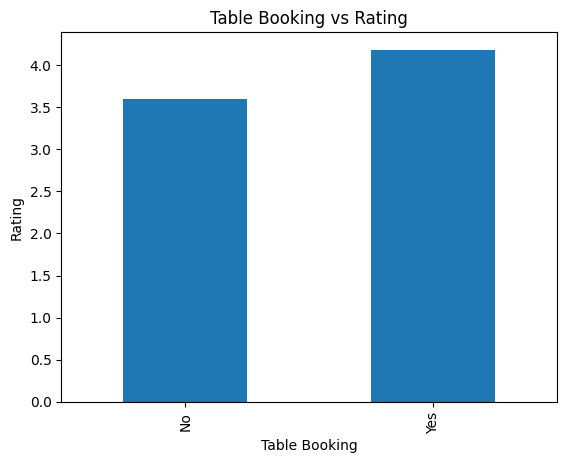

In [86]:
# 2. Table Booking vs Rating

df.groupby('book_table')['rate'].mean().plot(kind='bar')
plt.xlabel("Table Booking")
plt.ylabel("Rating")
plt.title("Table Booking vs Rating")
plt.show()

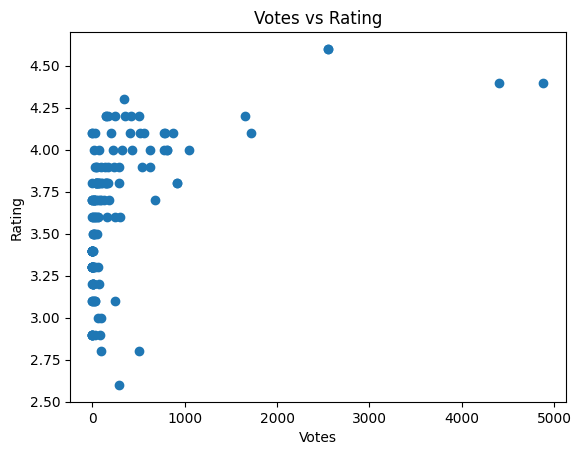

In [87]:
# 3. Votes vs Rating

plt.scatter(df['votes'], df['rate'])
plt.xlabel("Votes")
plt.ylabel("Rating")
plt.title("Votes vs Rating")
plt.show()

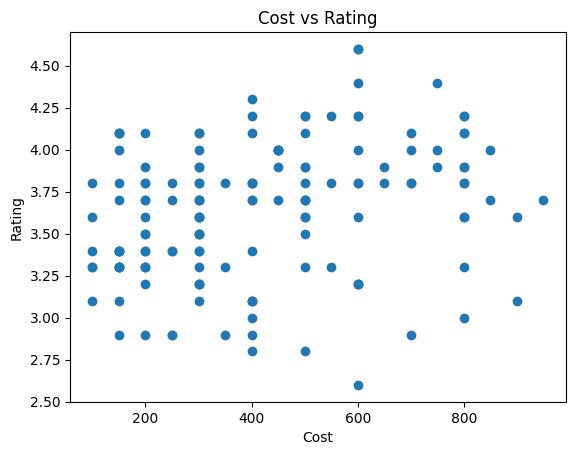

In [88]:
# 4. Cost vs Rating

plt.scatter(df['approx_cost(for two people)'], df['rate'])
plt.xlabel("Cost")
plt.ylabel("Rating")
plt.title("Cost vs Rating")
plt.show()

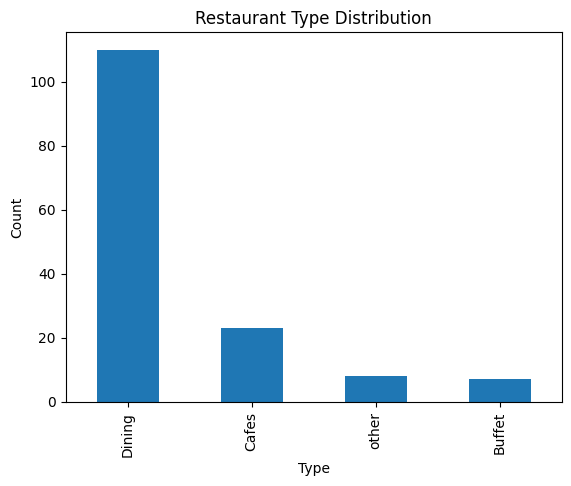

In [89]:
# 5. Restaurant Type
df['listed_in(type)'].value_counts().plot(kind='bar')
plt.title("Restaurant Type Distribution")
plt.xlabel("Type")
plt.ylabel("Count")
plt.show()

In [90]:
print("Total Restaurants:", df.shape[0])
print("Average Rating:", round(df['rate'].mean(), 2))
print("Most Common Restaurant Type:", df['listed_in(type)'].mode()[0])
print("Most Common Locations:", df['listed_in(city)'].mode()[0] if 'listed_in(city)' in df.columns else "N/A")

Total Restaurants: 148
Average Rating: 3.63
Most Common Restaurant Type: Dining
Most Common Locations: N/A


In [91]:
print("""
Conclusion:
1. Most restaurant accept online orders.
2. Table booking is less common compared to online orders.
3. Average rating hovers around 3.5-4.0.
4. Cafe-type and Quick Bites restaurants dominate the dataset.
5. Cost and rating have a weak positive correlation - higher cost not always mean higher rating.
""")


Conclusion:
1. Most restaurant accept online orders.
2. Table booking is less common compared to online orders.
3. Average rating hovers around 3.5-4.0.
4. Cafe-type and Quick Bites restaurants dominate the dataset.
5. Cost and rating have a weak positive correlation - higher cost not always mean higher rating.



In [92]:
df.to_csv('clean_zomato.csv', index=False)
print("Cleaned dataset saved as 'clean_zomato.csv'")

Cleaned dataset saved as 'clean_zomato.csv'


In [93]:
from google.colab import files
files.download('clean_zomato.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>